### 1.4.2.2. Autonomous Equations and Stability

$$
\frac{dy}{dx} = f(y); \qquad f(c) = 0 \ \Rightarrow\ y(x) = c \ \text{is an equilibrium (critical point)} .
$$

**Explanation:**

An equation is **autonomous** when the independent variable does not appear on the right side, $y' = f(y)$. The zeros of $f$ are the **critical points** (equilibrium / stationary points); each gives a constant **equilibrium solution** $y = c$. The sign of $f(y)$ between consecutive critical points tells whether solutions increase or decrease there, information collected on the **phase line**. A critical point is an **attractor** (asymptotically stable) if nearby solutions move toward it, a **repeller** (unstable) if they move away, or **semi-stable** if attracting on one side and repelling on the other — exactly the stability classification the control and reinforcement-learning tracks use for equilibria.

**Intuition:**

Arrows on the phase line point toward an attractor, away from a repeller, and one-way past a semi-stable point.

<p align="center">
  <img src="../../../Figures/01040202_attractor_repeller_semistable.jpeg"
       alt="Phase lines showing an attractor, a repeller, and two semi-stable critical points"
       width="320">
</p>

**Numerical Example:**

The logistic equation $\dfrac{dP}{dt} = P(a - bP)$ with $a, b > 0$ is autonomous. Take $a = b = 1$, so $f(P) = P(1 - P)$. Critical points solve $f(P) = 0$:

$$
P(1 - P) = 0 \;\Rightarrow\; P = 0 \ \text{ or } \ P = 1 .
$$

These split the phase line into three intervals; check the sign of $f$ on each:

$$
P < 0:\ f < 0\ (\downarrow), \qquad 0 < P < 1:\ f > 0\ (\uparrow), \qquad P > 1:\ f < 0\ (\downarrow).
$$

At $P = 0$ the arrows point **away** (down below, up above) — a **repeller (unstable)**. At $P = 1$ the arrows point **toward** it (up below, down above) — an **attractor (asymptotically stable)**. The sign test is confirmed by the derivative $f'(P) = a - 2bP$: $f'(0) = 1 > 0$ (unstable) and $f'(1) = -1 < 0$ (stable). So every population with $P(0) > 0$ tends to the carrying capacity $P = 1$.

In [1]:
import sympy as sp

P = sp.symbols("P", real=True)
a, b = sp.symbols("a b", positive=True)
f = P * (a - b * P)

critical_points = sp.solve(f, P)
stability_derivative = sp.diff(f, P)

print("f(P) = P(a - bP)")
print("critical points :", critical_points)
for point in critical_points:
    slope_at_point = sp.simplify(stability_derivative.subs(P, point))
    label = "attractor (stable)" if slope_at_point < 0 else "repeller (unstable)"
    print(f"  P = {point}: f'(P) = {slope_at_point} -> {label}")

f(P) = P(a - bP)
critical points : [0, a/b]
  P = 0: f'(P) = a -> repeller (unstable)
  P = a/b: f'(P) = -a -> attractor (stable)


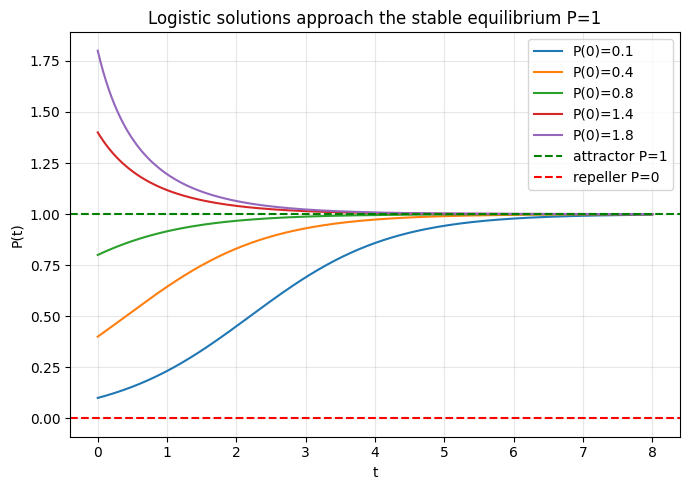

In [2]:
import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, 8, 200)
logistic = lambda initial: initial * np.exp(time) / (1 + initial * (np.exp(time) - 1))

plt.figure(figsize=(7, 5))
for initial in (0.1, 0.4, 0.8, 1.4, 1.8):
    plt.plot(time, logistic(initial), label=f"P(0)={initial}")
plt.axhline(1, color="green", linestyle="--", label="attractor P=1")
plt.axhline(0, color="red", linestyle="--", label="repeller P=0")
plt.xlabel("t"); plt.ylabel("P(t)"); plt.title("Logistic solutions approach the stable equilibrium P=1")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Direction Fields](./01_direction_fields.ipynb) | [Next: Separable Equations ➡️](./03_separable_equations.ipynb)